# 🧠 Section 09. Object Detection + R-CNN 계열
## CNN 구조와 영상 데이터 처리 실습

---
### 📌 이 노트북에서 배우는 것
- Bounding Box 두 가지 표현(xywh, xyxy)을 변환하고 시각화한다
- IoU를 단계별로 구현하고 torchvision 결과와 비교 검증한다
- NMS 알고리즘을 직접 구현하고 동작을 시각화한다
- Faster R-CNN 사전학습 모델로 실제 이미지에서 탐지 추론을 수행한다

### 📦 사용 데이터셋
| 항목 | 내용 |
|------|------|
| 이름 | 합성 Bounding Box 데이터 + matplotlib 내장 이미지 |
| 출처 | NumPy 직접 생성 + COCO 사전학습 모델 |

## ⚙️ 실습 전 필수 확인
```bash
conda env create -f environment.yml
conda activate cnn-course
jupyter lab
```

In [1]:
# ⚙️ 환경 설정
import torch, torchvision
import torch.nn as nn
from torchvision.ops import nms, box_iou
import matplotlib.pyplot as plt, matplotlib.patches as patches
import numpy as np

torch.manual_seed(42); np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {device} | PyTorch: {torch.__version__}")

✅ Device: cpu | PyTorch: 2.11.0+cpu


In [2]:
# ✅ 로컬 방식
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

nanum_fonts = [f for f in fm.fontManager.ttflist if 'Nanum' in f.name]

if nanum_fonts:
    font_path = nanum_fonts[0].fname          # 폰트 파일 경로 추출
    font_name = fm.FontProperties(fname=font_path).get_name()  # 실제 등록 이름 확인
    plt.rcParams['font.family'] = font_name
    print(f"✅ 적용 폰트: {font_name}")
else:
    plt.rcParams['font.family'] = 'Malgun Gothic'
    print("⚠️ 나눔 폰트 없음 → 맑은 고딕 적용")

plt.rcParams['axes.unicode_minus'] = False

⚠️ 나눔 폰트 없음 → 맑은 고딕 적용


---
## 실습 1. Bounding Box 표현 방식 이해

객체 탐지에서 박스 위치를 숫자로 나타내는 방법은 두 가지입니다.

### 📖 두 가지 표현
| 형식 | 표기 | 의미 | 주로 쓰는 곳 |
|---|---|---|---|
| XYWH | `(cx, cy, w, h)` | 중심 좌표 + 너비·높이 | YOLO, 어노테이션 도구 |
| XYXY | `(x1, y1, x2, y2)` | 좌상단 + 우하단 꼭짓점 | torchvision, IoU 계산 |

같은 박스를 두 방식으로 나타낸 것입니다. 어느 상황에서 어떤 형식을 쓰느냐의 차이입니다.  
먼저 완성된 예시를 실행하며 차이를 확인합니다.

=== 같은 박스를 두 가지 방식으로 ===
XYWH (cx,cy,w,h):     [100, 80, 80, 60]
XYXY (x1,y1,x2,y2):   [60, 50, 140, 110]


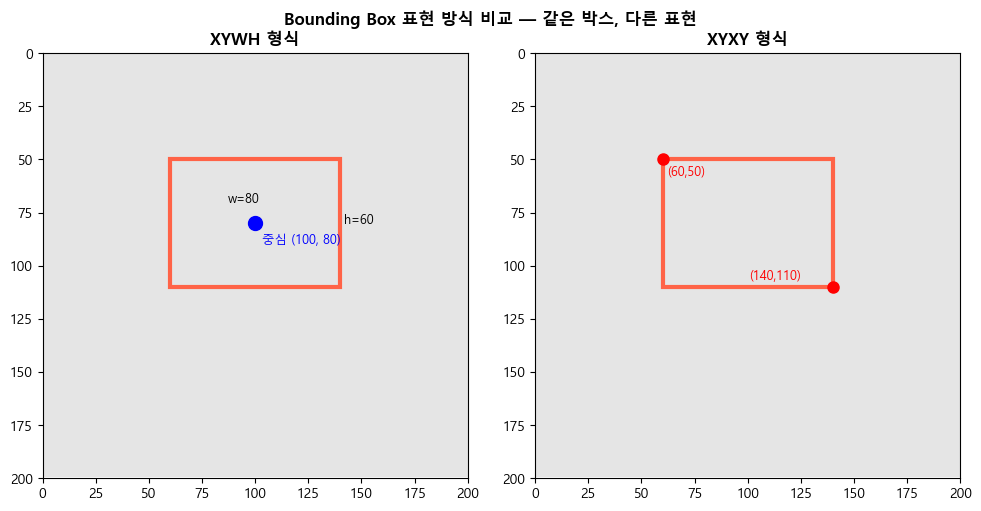

In [3]:
# ─────────────────────────────────────────────
# 1-1. 두 가지 Bounding Box 형식 비교 — 먼저 실행
# ─────────────────────────────────────────────

# 같은 박스를 두 가지 방법으로 표현
# (이미지 200×200 기준)

# XYWH 형식: 중심(100,80), 너비 80, 높이 60
box_xywh = [100, 80, 80, 60]   # cx, cy, w, h

# 같은 박스를 XYXY 형식으로
# x1 = cx - w/2 = 100-40 = 60
# y1 = cy - h/2 = 80-30  = 50
# x2 = cx + w/2 = 100+40 = 140
# y2 = cy + h/2 = 80+30  = 110
box_xyxy = [60, 50, 140, 110]  # x1, y1, x2, y2

print("=== 같은 박스를 두 가지 방식으로 ===")
print(f"XYWH (cx,cy,w,h):     {box_xywh}")
print(f"XYXY (x1,y1,x2,y2):   {box_xyxy}")

# 시각화로 비교
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, title in zip(axes, ["XYWH 형식", "XYXY 형식"]):
    ax.set_xlim(0,200); ax.set_ylim(200,0)
    ax.set_aspect('equal')
    ax.imshow(np.ones((200,200,3))*0.9)   # 밝은 배경
    rect = patches.Rectangle((60,50), 80, 60, lw=3, edgecolor='tomato', facecolor='none')
    ax.add_patch(rect)
    ax.set_title(title, fontsize=12, fontweight='bold')

# XYWH에 중심점 표시
axes[0].plot(100, 80, 'bo', markersize=10)
axes[0].annotate("중심 (100, 80)", (100,80), textcoords="offset points", xytext=(5,-15), fontsize=9, color='blue')
axes[0].annotate("w=80", (100,80), textcoords="offset points", xytext=(-20,15), fontsize=9)
axes[0].annotate("h=60", (140,80), textcoords="offset points", xytext=(3,0), fontsize=9)

# XYXY에 꼭짓점 표시
axes[1].plot([60,140], [50,110], 'ro', markersize=8)
axes[1].annotate("(60,50)", (60,50), textcoords="offset points", xytext=(3,-12), fontsize=9, color='red')
axes[1].annotate("(140,110)", (140,110), textcoords="offset points", xytext=(-60,5), fontsize=9, color='red')

plt.suptitle("Bounding Box 표현 방식 비교 — 같은 박스, 다른 표현", fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

In [4]:
# ─────────────────────────────────────────────
# 1-2. XYWH ↔ XYXY 변환 완성 예시
# ─────────────────────────────────────────────

def xywh_to_xyxy_example(boxes):
    """(cx,cy,w,h) → (x1,y1,x2,y2) 변환 (완성 예시)."""
    cx, cy, w, h = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    return torch.stack([cx - w/2, cy - h/2, cx + w/2, cy + h/2], dim=1)

# 테스트
test_boxes = torch.tensor([[100.,80.,80.,60.], [50.,50.,40.,40.]])
result = xywh_to_xyxy_example(test_boxes)
print("XYWH:", test_boxes.tolist())
print("XYXY:", result.tolist())

XYWH: [[100.0, 80.0, 80.0, 60.0], [50.0, 50.0, 40.0, 40.0]]
XYXY: [[60.0, 50.0, 140.0, 110.0], [30.0, 30.0, 70.0, 70.0]]


### ✏️ 이제 직접 구현해봅시다

반대 방향 변환(XYXY → XYWH)을 구현하세요.  
공식: `cx = (x1+x2)/2`, `cy = (y1+y2)/2`, `w = x2-x1`, `h = y2-y1`

In [ ]:
# ─────────────────────────────────────────────
# 1-3. ✏️ TODO: XYXY → XYWH 변환 구현
# ─────────────────────────────────────────────

def xyxy_to_xywh(boxes):
    """
    (x1,y1,x2,y2) 형식을 (cx,cy,w,h) 형식으로 변환합니다.

    Args:
        boxes (Tensor): (N, 4) 형태, 각 행은 [x1, y1, x2, y2]
    Returns:
        Tensor: (N, 4) 형태, 각 행은 [cx, cy, w, h]
    """
    x1, y1, x2, y2 = boxes[:,0], boxes[:,1], boxes[:,2], boxes[:,3]
    cx = (___ + ___) / 2   # 힌트: x1과 x2의 평균
    cy = (___ + ___) / 2   # 힌트: y1과 y2의 평균
    w  = ___ - ___          # 힌트: 가로 폭
    h  = ___ - ___          # 힌트: 세로 높이
    return torch.stack([cx, cy, w, h], dim=1)

print("xyxy_to_xywh를 완성한 뒤 다음 셀을 실행하세요!")

In [5]:
# 💡 정답 확인 (먼저 스스로 풀어보세요!)
# -------------------------------------------
def xyxy_to_xywh(boxes):
    x1,y1,x2,y2 = boxes[:,0],boxes[:,1],boxes[:,2],boxes[:,3]
    return torch.stack([(x1+x2)/2,(y1+y2)/2,x2-x1,y2-y1],dim=1)
print("✅ xyxy_to_xywh 정답 로드!")

✅ xyxy_to_xywh 정답 로드!


In [6]:
# 변환 → 역변환 → 원본과 일치 검증
original = torch.tensor([[100.,80.,80.,60.],[50.,50.,40.,40.]])
xyxy = xywh_to_xyxy_example(original)
back = xyxy_to_xywh(xyxy)
print("원본 XYWH:  ", original.tolist())
print("→ XYXY:    ", xyxy.tolist())
print("→ 역변환:  ", back.tolist())
diff = (original - back).abs().max().item()
print(f"\n최대 오차: {diff:.6f}  (0이면 완벽한 역변환)")

원본 XYWH:   [[100.0, 80.0, 80.0, 60.0], [50.0, 50.0, 40.0, 40.0]]
→ XYXY:     [[60.0, 50.0, 140.0, 110.0], [30.0, 30.0, 70.0, 70.0]]
→ 역변환:   [[100.0, 80.0, 80.0, 60.0], [50.0, 50.0, 40.0, 40.0]]

최대 오차: 0.000000  (0이면 완벽한 역변환)


---
## 실습 2. IoU — 박스 겹침 측정

IoU(Intersection over Union)는 두 박스가 얼마나 겹치는지를 0~1 사이 값으로 나타냅니다.

### 📖 IoU 공식
```
IoU = 교집합 넓이 / 합집합 넓이
    = TP / (TP + FP + FN)
```

탐지에서 IoU가 중요한 이유:
- **평가**: 예측 박스의 IoU ≥ 0.5면 올바른 탐지(TP)로 판정
- **NMS**: 겹치는 박스 제거 시 기준값으로 사용

먼저 완성된 예시로 IoU 계산 과정을 이해합니다.

In [ ]:
# ─────────────────────────────────────────────
# 2-1. IoU 계산 완성 예시 — 단계별 확인
# ─────────────────────────────────────────────

def compute_iou_example(box1, box2):
    """
    두 박스의 IoU를 계산합니다 (XYXY 형식, 완성 예시).
    박스: [x1, y1, x2, y2]
    """
    # ① 교집합 좌표 계산
    ix1 = max(box1[0], box2[0])   # 더 오른쪽의 왼쪽 경계
    iy1 = max(box1[1], box2[1])   # 더 아래쪽의 위쪽 경계
    ix2 = min(box1[2], box2[2])   # 더 왼쪽의 오른쪽 경계
    iy2 = min(box1[3], box2[3])   # 더 위쪽의 아래쪽 경계

    # ② 교집합 넓이 (겹치지 않으면 0)
    inter_w = max(0, ix2 - ix1)
    inter_h = max(0, iy2 - iy1)
    intersection = inter_w * inter_h

    # ③ 각 박스의 넓이
    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])

    # ④ 합집합 = 합 - 교집합
    union = area1 + area2 - intersection

    return intersection / union if union > 0 else 0.0

# 케이스별 IoU 확인
b1 = [50, 50, 150, 150]   # 100×100 박스

# 완벽히 겹침
b_same = [50, 50, 150, 150]
# 절반 겹침 (오른쪽으로 50 이동)
b_half = [100, 50, 200, 150]
# 전혀 안 겹침
b_none = [200, 200, 300, 300]

print(f"완전히 같은 박스:   IoU = {compute_iou_example(b1, b_same):.4f}  (1.0이어야 함)")
print(f"절반 겹치는 박스:   IoU = {compute_iou_example(b1, b_half):.4f}  (0.333...)")
print(f"전혀 안 겹치는 박스: IoU = {compute_iou_example(b1, b_none):.4f}  (0.0이어야 함)")

완전히 같은 박스:   IoU = 1.0000  (1.0이어야 함)
절반 겹치는 박스:   IoU = 0.3333  (0.333...)
전혀 안 겹치는 박스: IoU = 0.0000  (0.0이어야 함)


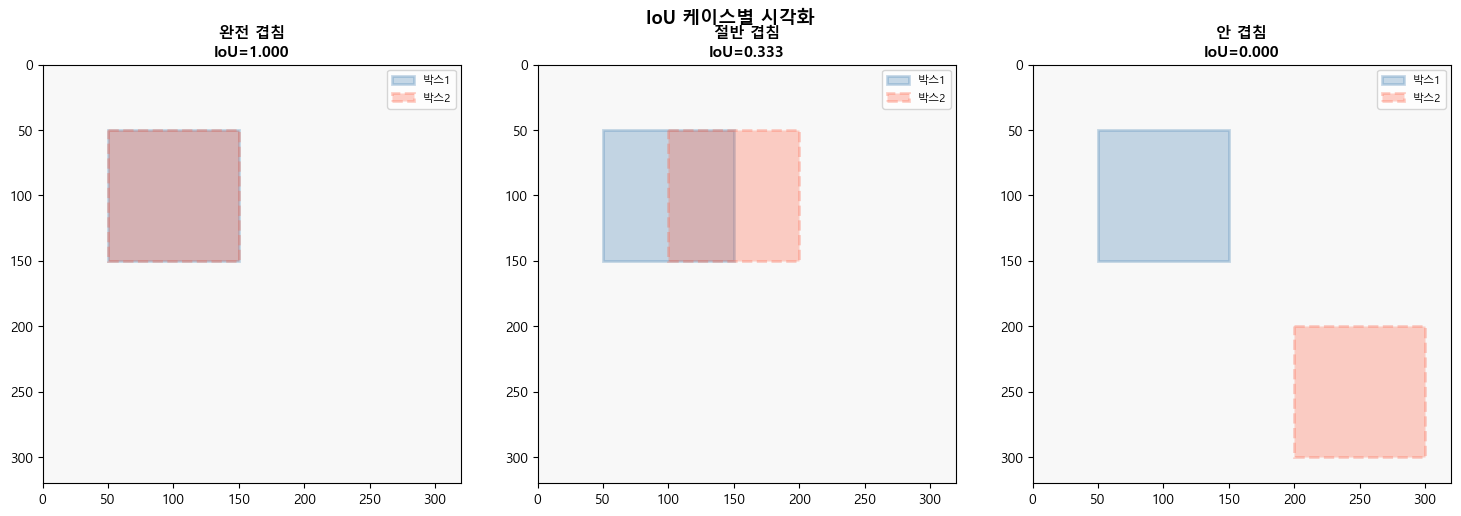

In [10]:
# IoU 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cases = [
    ([50, 50, 150, 150], "완전 겹침\nIoU=1.000"),
    ([100, 50, 200, 150], "절반 겹침\nIoU=0.333"),
    ([200, 200, 300, 300], "안 겹침\nIoU=0.000"),
]

for ax, (b2, title) in zip(axes, cases):
    ax.set_xlim(0,320); ax.set_ylim(320,0); ax.set_aspect('equal')
    ax.set_facecolor('#f8f8f8')
    r1 = patches.Rectangle((50,50),100,100,lw=2,edgecolor='steelblue',facecolor='steelblue',alpha=0.3,label='박스1')
    r2 = patches.Rectangle((b2[0], b2[1]), b2[2]-b2[0], b2[3]-b2[1], lw=2, linestyle='--', edgecolor='tomato', facecolor='tomato', alpha=0.3, label='박스2')
    ax.add_patch(r1)
    ax.add_patch(r2)
    ax.legend(loc='upper right', fontsize=8)
    ax.set_title(title, fontsize=11, fontweight='bold')

plt.suptitle("IoU 케이스별 시각화", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### ✏️ 이제 직접 구현해봅시다

위 예시를 참고해서 Tensor 기반의 `compute_iou` 함수를 구현하고  
`torchvision.ops.box_iou`와 비교 검증합니다.

In [ ]:
# ─────────────────────────────────────────────
# 2-2. ✏️ TODO: Tensor 기반 IoU 구현
# ─────────────────────────────────────────────

def compute_iou(box1, box2):
    """
    두 박스의 IoU를 계산합니다 (XYXY 형식, Tensor 입력).

    Args:
        box1, box2 (Tensor): shape (4,), [x1,y1,x2,y2]
    Returns:
        float: IoU 값
    """
    # ① 교집합 좌표
    ix1 = torch.___(box1[0], box2[0])   # 힌트: 두 값 중 최댓값
    iy1 = torch.___(box1[1], box2[1])
    ix2 = torch.___(box1[2], box2[2])   # 힌트: 두 값 중 최솟값
    iy2 = torch.___(box1[3], box2[3])

    # ② 교집합 넓이
    inter = (___ - ___, torch.tensor(0.)).max() *             (___ - ___, torch.tensor(0.)).max()
    # 힌트: max(0, ix2-ix1) * max(0, iy2-iy1)

    # ③ 합집합
    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union = area1 + area2 - inter

    return (inter / union).item() if union > 0 else 0.0

print("compute_iou를 완성한 뒤 다음 셀을 실행하세요!")

In [11]:
# 💡 정답 확인 (먼저 스스로 풀어보세요!)
# -------------------------------------------
def compute_iou(box1, box2):
    ix1=torch.max(box1[0],box2[0]); iy1=torch.max(box1[1],box2[1])
    ix2=torch.min(box1[2],box2[2]); iy2=torch.min(box1[3],box2[3])
    inter=torch.clamp(ix2-ix1,min=0)*torch.clamp(iy2-iy1,min=0)
    area1=(box1[2]-box1[0])*(box1[3]-box1[1])
    area2=(box2[2]-box2[0])*(box2[3]-box2[1])
    union=area1+area2-inter
    return (inter/union).item() if union>0 else 0.0
print("✅ compute_iou 정답 로드!")

✅ compute_iou 정답 로드!


In [12]:
# torchvision box_iou와 비교 검증
b1 = torch.tensor([50., 50., 150., 150.])
b2 = torch.tensor([100., 50., 200., 150.])

my_iou = compute_iou(b1, b2)
tv_iou = box_iou(b1.unsqueeze(0), b2.unsqueeze(0)).item()

print(f"직접 구현 IoU: {my_iou:.6f}")
print(f"torchvision  IoU: {tv_iou:.6f}")
print(f"최대 오차: {abs(my_iou - tv_iou):.8f}")
assert abs(my_iou - tv_iou) < 1e-4, "구현을 확인하세요!"
print("✅ torchvision과 일치!")

직접 구현 IoU: 0.333333
torchvision  IoU: 0.333333
최대 오차: 0.00000000
✅ torchvision과 일치!


---
## 실습 3. NMS — 중복 박스 제거

### 📖 왜 NMS가 필요한가?

탐지 모델은 이미지를 그리드로 나눠 각 위치에서 독립적으로 박스를 예측합니다.  
하나의 고양이 주변 여러 그리드 셀이 모두 "고양이 박스"를 예측합니다.  
NMS는 이 중 **가장 좋은 박스 하나만 남기고 나머지를 제거합니다.**

### 📖 NMS 알고리즘 (4단계)

```
1. 신뢰도(score) 내림차순 정렬
2. 가장 높은 박스를 keep에 추가
3. 선택된 박스와 IoU > threshold 인 박스들을 모두 제거
4. 남은 박스가 있으면 2번으로 반복
```

> 💡 **핵심 직관**  
> "반장 선거"와 같습니다.  
> 가장 득표가 많은(신뢰도 높은) 후보를 뽑고,  
> 그 후보와 "너무 비슷한"(IoU가 높은) 다른 후보들을 탈락시킵니다.

> ⚠️ **IoU threshold 선택**:  
> 너무 낮으면(0.3) 가까이 있는 서로 다른 객체를 하나로 합쳐버립니다.  
> 너무 높으면(0.9) 같은 객체에 박스가 여러 개 남습니다.  
> 일반적으로 **0.45~0.5** 를 사용합니다.

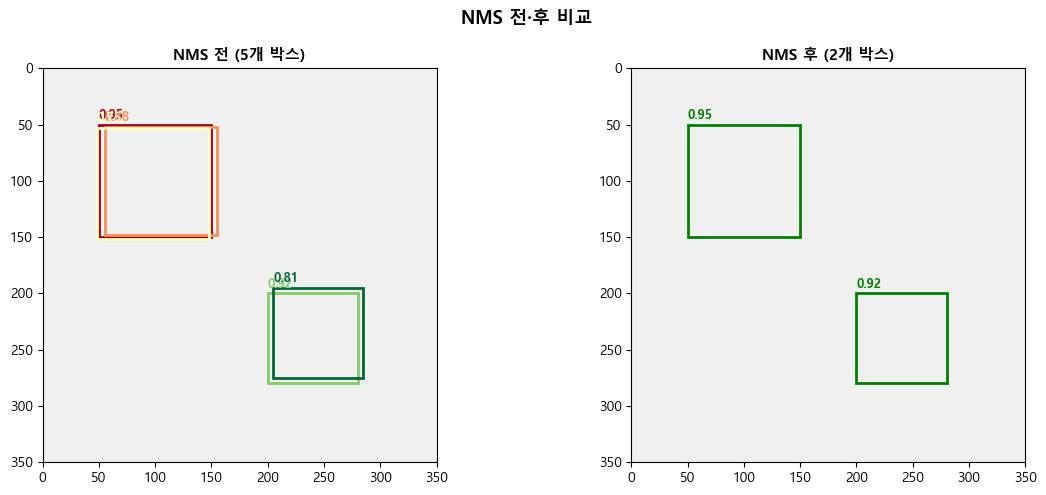

NMS 전: 5개 → NMS 후: 2개
유지된 박스 인덱스: [0, 3]


In [13]:
# ─────────────────────────────────────────────
# 3-1. NMS 전·후 시각화 — 먼저 실행
# ─────────────────────────────────────────────
from torchvision.ops import nms

# 같은 객체 주변에 여러 박스가 겹침 (실제 탐지 모델의 출력 시뮬레이션)
boxes = torch.tensor([
    [50.,50.,150.,150.],   # 메인 박스 (score 0.95)
    [55.,52.,155.,148.],   # 거의 같은 위치 (score 0.88)
    [48.,53.,148.,152.],   # 약간 이동 (score 0.75)
    [200.,200.,280.,280.], # 다른 객체 (score 0.92)
    [205.,195.,285.,275.], # 다른 객체 인근 (score 0.81)
])
scores = torch.tensor([0.95, 0.88, 0.75, 0.92, 0.81])

# torchvision NMS 적용
kept_indices = nms(boxes, scores, iou_threshold=0.5)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = plt.cm.RdYlGn(np.linspace(0,1,len(boxes)))

for ax, (title, show_all) in zip(axes, [("NMS 전 (5개 박스)", True), ("NMS 후 (2개 박스)", False)]):
    ax.set_xlim(0,350); ax.set_ylim(350,0); ax.set_aspect('equal')
    ax.set_facecolor('#f0f0f0')
    indices_to_show = range(len(boxes)) if show_all else kept_indices.tolist()
    for i in indices_to_show:
        b = boxes[i]; s = scores[i]
        color = colors[i] if show_all else 'green'
        rect = patches.Rectangle((b[0],b[1]),(b[2]-b[0]),(b[3]-b[1]),lw=2,edgecolor=color,facecolor='none')
        ax.add_patch(rect)
        ax.text(b[0],b[1]-5,f"{s:.2f}",color=color,fontsize=9,fontweight='bold')
    ax.set_title(title, fontsize=11, fontweight='bold')

plt.suptitle("NMS 전·후 비교", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print(f"NMS 전: {len(boxes)}개 → NMS 후: {len(kept_indices)}개")
print(f"유지된 박스 인덱스: {kept_indices.tolist()}")

### ✏️ 이제 직접 구현해봅시다

In [ ]:
# ─────────────────────────────────────────────
# 3-2. ✏️ TODO: NMS 직접 구현
# ─────────────────────────────────────────────

def nms_manual(boxes, scores, iou_threshold=0.5):
    """
    Non-Maximum Suppression으로 중복 박스를 제거합니다.

    Args:
        boxes         (Tensor): (N, 4) [x1,y1,x2,y2]
        scores        (Tensor): (N,) 신뢰도 점수
        iou_threshold (float): 이 값보다 IoU가 높으면 제거

    Returns:
        Tensor: 유지할 박스의 인덱스
    """
    # ① 신뢰도 기준 내림차순 정렬
    order = scores.argsort(descending=___)   # 힌트: 내림차순이면 True
    keep  = []

    while order.numel() > 0:
        # ② 현재 가장 높은 점수의 박스 선택
        idx = order[0].item()
        keep.append(idx)

        if order.numel() == 1:
            break

        # ③ 나머지 박스들과 IoU 계산
        rest = order[1:]
        ious = box_iou(boxes[idx].unsqueeze(0), boxes[rest]).squeeze(0)

        # ④ IoU가 threshold 이하인 박스만 유지 (겹치지 않는 것만)
        mask = ious ___ iou_threshold   # 힌트: <= 비교 연산자
        order = rest[mask]

    return torch.tensor(keep, dtype=torch.long)

print("nms_manual을 완성한 뒤 다음 셀을 실행하세요!")

In [14]:
# 💡 정답 확인 (먼저 스스로 풀어보세요!)
# -------------------------------------------
def nms_manual(boxes, scores, iou_threshold=0.5):
    order=scores.argsort(descending=True); keep=[]
    while order.numel()>0:
        idx=order[0].item(); keep.append(idx)
        if order.numel()==1: break
        rest=order[1:]
        ious=box_iou(boxes[idx].unsqueeze(0),boxes[rest]).squeeze(0)
        mask=ious<=iou_threshold
        order=rest[mask]
    return torch.tensor(keep,dtype=torch.long)
print("✅ nms_manual 정답 로드!")

✅ nms_manual 정답 로드!


In [15]:
# torchvision NMS와 비교 검증
my_kept = nms_manual(boxes, scores, iou_threshold=0.5)
tv_kept = nms(boxes, scores, iou_threshold=0.5)

print(f"직접 구현 NMS: {sorted(my_kept.tolist())} (유지 {len(my_kept)}개)")
print(f"torchvision  NMS: {sorted(tv_kept.tolist())} (유지 {len(tv_kept)}개)")
assert set(my_kept.tolist()) == set(tv_kept.tolist()), "결과가 다릅니다!"
print("✅ torchvision NMS와 결과 일치!")

직접 구현 NMS: [0, 3] (유지 2개)
torchvision  NMS: [0, 3] (유지 2개)
✅ torchvision NMS와 결과 일치!


---
## 실습 4. Faster R-CNN 사전학습 모델 추론

### 📖 Faster R-CNN의 처리 흐름

```
이미지
→ Backbone (ResNet50+FPN)  : 멀티스케일 특징 맵 추출
→ RPN (Region Proposal)    : 객체가 있을 것 같은 영역 제안 (~300개)
→ ROI Align                : 각 제안 영역의 특징 추출
→ Classification Head      : 클래스 예측
→ Regression Head          : 박스 좌표 정제
→ NMS                      : 중복 제거 → 최종 결과
```

> 💡 **핵심 직관**  
> Faster R-CNN은 "경비원이 수상한 사람 목록을 먼저 만들고(RPN),  
> 보안팀이 그 목록의 각 사람을 정밀 조사(Head)"하는 2-Stage 구조입니다.

> ⚠️ **torchvision 탐지 모델 입력 형식**:  
> 분류 모델과 달리 `List[Tensor]` 형태로 이미지를 입력합니다.  
> 각 텐서는 `(C, H, W)` 형태이며, 배치가 아닌 리스트로 묶습니다.  
> `detector([img_tensor])` 또는 `detector(img_batch)` 모두 가능합니다.

In [16]:
# ─────────────────────────────────────────────
# 4-1. Faster R-CNN 로드 및 구조 확인
# ─────────────────────────────────────────────
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights

weights = FasterRCNN_ResNet50_FPN_Weights.COCO_V1
detector = fasterrcnn_resnet50_fpn(weights=weights)
detector.eval()
detector = detector.to(device)

COCO_LABELS = weights.meta['categories']
print(f"모델 로드 완료")
print(f"COCO 클래스 수: {len(COCO_LABELS)}")
print(f"클래스 예시: {COCO_LABELS[:10]}")

# 파라미터 수 확인
total_params = sum(p.numel() for p in detector.parameters())
print(f"총 파라미터 수: {total_params:,}")

0.4%

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to C:\Users\hanmi/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100.0%


모델 로드 완료
COCO 클래스 수: 91
클래스 예시: ['__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat']
총 파라미터 수: 41,755,286


In [ ]:
# ─────────────────────────────────────────────
# 4-2. 이미지 로드 및 전처리
# ─────────────────────────────────────────────

img_np = plt.imread(plt.matplotlib.cbook.get_sample_data('grace_hopper.jpg'))
print(f"이미지 shape: {img_np.shape}  (H, W, C)")
print(f"픽셀값 범위: {img_np.min()} ~ {img_np.max()}")

# ✏️ 빈칸: numpy 이미지를 PyTorch 텐서로 변환
# 힌트: torchvision.transforms.functional.to_tensor 사용
img_tensor = torchvision.transforms.functional.___(img_np)
img_batch  = img_tensor.unsqueeze(0).to(device)   # 배치 차원 추가

print(f"\n텐서 shape: {img_batch.shape}  (N, C, H, W)")
print(f"픽셀값 범위: {img_batch.min():.3f} ~ {img_batch.max():.3f}  ← 0~1로 정규화됨")

이미지 shape: (600, 512, 3)  (H, W, C)
픽셀값 범위: 0 ~ 255

텐서 shape: torch.Size([1, 3, 600, 512])  (N, C, H, W)
픽셀값 범위: 0.000 ~ 1.000  ← 0~1로 정규화됨


c:\Users\hanmi\miniconda3\envs\cnn-course\lib\site-packages\torchvision\transforms\functional.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  img = torch.from_numpy(pic.transpose((2, 0, 1))).contiguous()


In [ ]:
# 💡 정답 확인 (먼저 스스로 풀어보세요!)
# -------------------------------------------
# img_tensor = torchvision.transforms.functional.to_tensor(img_np)
print("torchvision.transforms.functional.to_tensor(img_np)")

탐지된 총 박스 수 (NMS 후): 17
박스 shape:  torch.Size([17, 4])
점수 shape:  torch.Size([17])
레이블 shape: torch.Size([17])

신뢰도 0.5 이상 박스: 2개


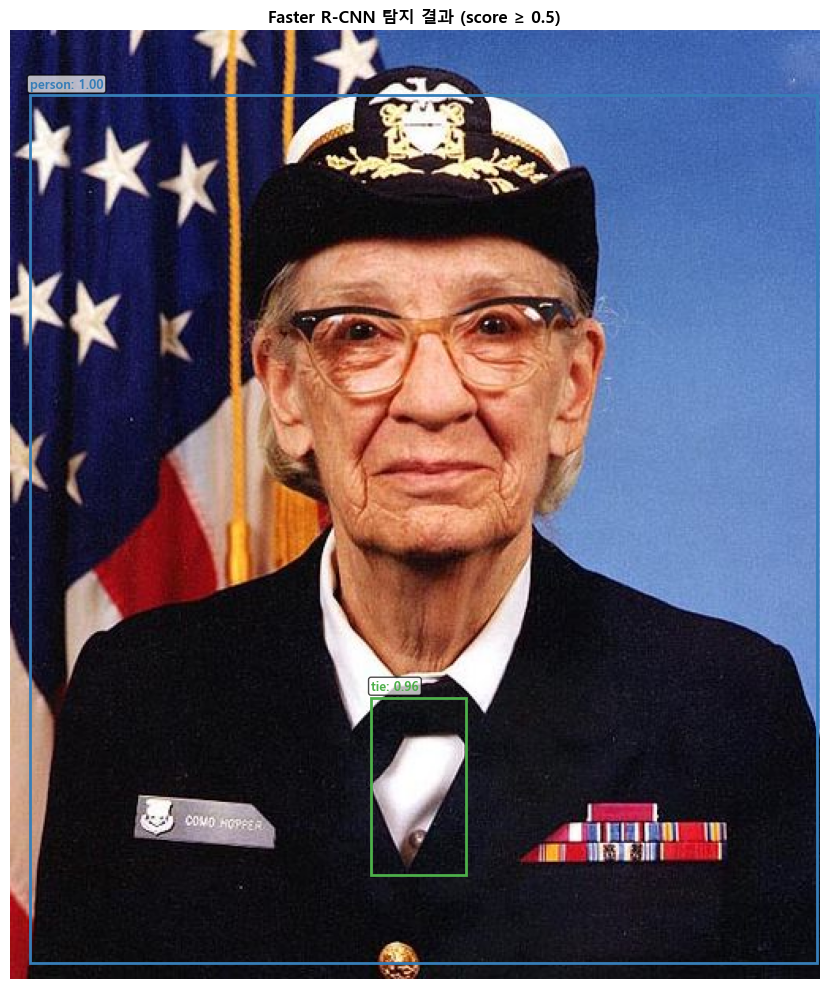

In [18]:
# ─────────────────────────────────────────────
# 4-3. 탐지 추론 및 결과 시각화
# ─────────────────────────────────────────────

with torch.no_grad():
    predictions = detector(img_batch)

pred = predictions[0]
print(f"탐지된 총 박스 수 (NMS 후): {len(pred['boxes'])}")
print(f"박스 shape:  {pred['boxes'].shape}")
print(f"점수 shape:  {pred['scores'].shape}")
print(f"레이블 shape: {pred['labels'].shape}")

# 신뢰도 0.5 이상 필터링
threshold = 0.5
mask   = pred['scores'] > threshold
boxes_f  = pred['boxes'][mask].cpu()
scores_f = pred['scores'][mask].cpu()
labels_f = pred['labels'][mask].cpu()
print(f"\n신뢰도 {threshold} 이상 박스: {mask.sum().item()}개")

# 시각화
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(img_np)
color_map = plt.cm.Set1(np.linspace(0,1,10))

for box, score, label in zip(boxes_f, scores_f, labels_f):
    x1,y1,x2,y2 = box.tolist()
    c = color_map[label.item() % 10]
    rect = patches.Rectangle((x1,y1),(x2-x1),(y2-y1), lw=2, edgecolor=c, facecolor='none')
    ax.add_patch(rect)
    cls_name = COCO_LABELS[label.item()] if label.item() < len(COCO_LABELS) else str(label.item())
    ax.text(x1, y1-5, f"{cls_name}: {score:.2f}", color=c, fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

ax.set_title(f"Faster R-CNN 탐지 결과 (score ≥ {threshold})", fontweight='bold')
ax.axis('off'); plt.tight_layout(); plt.show()

---
## 🚀 도전 과제

### 과제 1. Confidence Threshold 실험
threshold를 0.3, 0.5, 0.7, 0.9로 바꿔가며 탐지 결과를 4개 나란히 시각화하세요.  
threshold가 높아질수록 Precision/Recall이 어떻게 변하는지 분석하세요.

### 과제 2. IoU 임계값 NMS 비교  
같은 이미지에 `iou_threshold=0.3, 0.5, 0.8`로 NMS를 적용하고  
각각 몇 개의 박스가 남는지 비교하세요.

### 과제 3. 직접 촬영한 이미지 테스트
스마트폰으로 직접 촬영한 사진으로 Faster R-CNN 추론을 수행하고  
어떤 객체를 탐지하는지, 어디서 실패하는지 분석하세요.
